# DS 4320 Project 2 — Analysis Pipeline
## Forecasting S&P 500 Sector ETF Price Direction Using Price and Macroeconomic Signals
**Emujin Batzorig | DS 4320 Spring 2026**

---

This notebook is the full analysis pipeline for Project 2. It does five things in order:
1. Queries both MongoDB collections and loads them into DataFrames
2. Merges and cleans the data into a single modeling dataset
3. Engineers features from raw price and macro data
4. Trains and evaluates a Random Forest classifier to predict next-day price direction
5. Produces publication-quality visualizations and interprets the results

Every decision is explained inline.

---

## Stage 1 — Data Preparation: Query MongoDB into DataFrames

In [ ]:
import os
import logging
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pymongo import MongoClient
# from dotenv import load_dotenv # Not needed when using Colab secrets
from google.colab import userdata # Import userdata for Colab secrets

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

# load_dotenv() # Not needed when using Colab secrets
# client = MongoClient(os.getenv("MONGO_URI")) # Original line
client = MongoClient(userdata.get("MONGO_URI")) # Use Colab secrets
db     = client["stock_forecast"]

logger.info("Connected to MongoDB Atlas")

In [ ]:
# ---- 1a. Load prices collection ----
# Each document = one trading day for one ETF

prices_cursor = db["prices"].find({}, {"_id": 0})
prices_df     = pd.DataFrame(list(prices_cursor))

logger.info("Prices loaded: %d documents", len(prices_df))
logger.info("Tickers: %s", sorted(prices_df["ticker"].unique().tolist()))
logger.info("Date range: %s to %s", prices_df["date"].min(), prices_df["date"].max())
prices_df.head(3)

,date,ticker,close,direction,high,ingested_at,low,open,pct_change,volume
0,2020-01-03,XLK,43.7962,0,44.0997,2026-04-16T15:26:44.795005,43.6444,43.6491,-0.011243,30023600
1,2020-01-06,XLK,43.9005,1,43.9480,2026-04-16T15:26:44.823181,43.2792,43.3598,0.002383,15630000
2,2020-01-07,XLK,43.8815,0,44.0997,2026-04-16T15:26:44.891001,43.8151,43.9764,-0.000432,15363600


In [ ]:
# ---- 1b. Load macro_indicators collection ----
# Each document = one trading day's economic snapshot, shared by all tickers

macro_cursor = db["macro_indicators"].find({}, {"_id": 0})
macro_df     = pd.DataFrame(list(macro_cursor))

# Drop internal forward-fill tracking columns (not model features)
fill_cols = [c for c in macro_df.columns if c.startswith("_")]
macro_df  = macro_df.drop(columns=fill_cols, errors="ignore")

logger.info("Macro loaded: %d documents", len(macro_df))
macro_df.head(3)

,date,consumer_sentiment,cpi_yoy,fed_funds_rate,ingested_at,treasury_10yr,unemployment_rate,vix
0,2020-01-01,99.8,NaN,1.55,2026-04-16T17:03:11.119381,NaN,3.6,NaN
1,2020-01-02,99.8,NaN,1.55,2026-04-16T17:03:11.140630,1.88,3.6,12.47
2,2020-01-03,99.8,NaN,1.55,2026-04-16T17:03:11.157614,1.80,3.6,14.02


# 2 - Merging and Cleaning

In [ ]:
# Merge prices with macro on date
# This is a many-to-one join: every ETF on a given day gets the same macro values

merged = prices_df.merge(macro_df, on="date", how="left")
logger.info("After merge: %d rows", len(merged))

# Sort chronologically within each ticker (critical for lag features)
merged = merged.sort_values(["ticker", "date"]).reset_index(drop=True)

# Drop rows missing macro data (very early dates before FRED coverage begins)
before = len(merged)
merged = merged.dropna(subset=["fed_funds_rate", "vix", "treasury_10yr"])
logger.info("Dropped %d rows with missing macro data", before - len(merged))

print(f"Final dataset: {len(merged):,} rows x {merged.shape[1]} columns")
print(f"Date range: {merged['date'].min()} to {merged['date'].max()}")

Final dataset: 13,816 rows x 17 columns
Date range: 2020-01-03 to 2024-12-30


In [ ]:
# Class balance check
direction_counts = merged["direction"].value_counts(normalize=True)
print(f"Up (1):   {direction_counts.get(1, 0):.1%}")
print(f"Down (0): {direction_counts.get(0, 0):.1%}")
print()
print("Per-ticker direction rates:")
print(merged.groupby("ticker")["direction"].mean().sort_values(ascending=False).round(3).to_string())

Up (1):   53.0%
Down (0): 47.0%

Per-ticker direction rates:
ticker
XLK     0.544
XLY     0.543
XLC     0.542
XLI     0.535
XLU     0.526
XLP     0.525
XLB     0.525
XLE     0.525
XLRE    0.523
XLF     0.521
XLV     0.517


## Stage 3 — Feature Engineering

Two categories of features:
- **Price / technical:** lagged returns, moving averages, RSI, volatility, intraday range, volume ratio
- **Macroeconomic:** rate levels and daily changes in VIX, fed funds rate, and Treasury yield

In [ ]:
def add_technical_features(df):
    """
    Computes price-derived technical indicator features per ticker.
    All computations are done within each ticker group to prevent
    data leakage across tickers.
    """
    def compute_for_ticker(group):
        g = group.copy().sort_values("date")

        # Momentum: lagged daily returns (did price go up yesterday? two days ago?)
        g["lag_ret_1"] = g["pct_change"].shift(1)
        g["lag_ret_2"] = g["pct_change"].shift(2)
        g["lag_ret_3"] = g["pct_change"].shift(3)

        # Trend: moving averages and how far today's price is from recent trend
        g["ma_5"]     = g["close"].rolling(5).mean()
        g["ma_20"]    = g["close"].rolling(20).mean()
        g["ma_ratio"] = g["close"] / g["ma_20"]  # above 1 = price above 20-day trend

        # Volatility: how much has price been moving recently?
        g["volatility_5"] = g["pct_change"].rolling(5).std()

        # RSI (14-day): measures speed and magnitude of recent price changes
        delta    = g["close"].diff()
        gain     = delta.clip(lower=0)
        loss     = -delta.clip(upper=0)
        avg_gain = gain.rolling(14).mean()
        avg_loss = loss.rolling(14).mean()
        rs       = avg_gain / avg_loss.replace(0, 1e-10)
        g["rsi_14"] = 100 - (100 / (1 + rs))

        # Intraday range: how wide was the price swing relative to close?
        g["high_low_range"] = (g["high"] - g["low"]) / g["close"]

        # Volume ratio: is today's trading volume unusual?
        g["volume_ratio"] = g["volume"] / g["volume"].rolling(20).mean()

        return g

    return df.groupby("ticker", group_keys=False).apply(compute_for_ticker)


def add_macro_change_features(df):
    """
    Adds one-day changes in daily macro series.
    A VIX spike from 15 to 25 is more informative than
    VIX sitting at 20 for a month, so changes matter alongside levels.
    """
    df = df.sort_values(["ticker", "date"])
    for col in ["vix", "fed_funds_rate", "treasury_10yr"]:
        df[f"{col}_change"] = df.groupby("ticker")[col].diff()
    return df


merged = add_technical_features(merged)
merged = add_macro_change_features(merged)

# Drop warmup rows with NaN from rolling windows (first ~20 days per ticker)
before = len(merged)
merged = merged.dropna(subset=["lag_ret_1", "ma_20", "rsi_14", "volatility_5"])
logger.info("Dropped %d warmup rows from rolling windows", before - len(merged))

print(f"Dataset ready for modeling: {len(merged):,} rows")

Dataset ready for modeling: 13,607 rows


In [ ]:
# Define feature sets by category
# Keeping them separate makes the feature importance chart more interpretable

PRICE_FEATURES = [
    "lag_ret_1", "lag_ret_2", "lag_ret_3",
    "ma_ratio", "volatility_5", "rsi_14",
    "high_low_range", "volume_ratio",
]

MACRO_FEATURES = [
    "fed_funds_rate", "treasury_10yr", "vix",
    "cpi_yoy", "unemployment_rate", "consumer_sentiment",
    "vix_change", "fed_funds_rate_change", "treasury_10yr_change",
]

ALL_FEATURES = PRICE_FEATURES + MACRO_FEATURES
TARGET       = "direction"

print(f"Price features:  {len(PRICE_FEATURES)}")
print(f"Macro features:  {len(MACRO_FEATURES)}")
print(f"Total:           {len(ALL_FEATURES)}")

Price features:  8
Macro features:  9
Total:           17


## Stage 4 — Model Training and Evaluation

**Why Random Forest?**
It handles mixed feature types without needing normalization, produces feature importance scores natively, and is robust to the kind of extreme values that show up in financial data (like the March 2020 crash).

**Why a time-based split?**
With time-series data, a random split would let the model train on future data relative to some of its test rows. Training on 2020-2022 and testing on 2023-2024 simulates real out-of-sample performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

SPLIT_DATE = "2023-01-01"
train = merged[merged["date"] < SPLIT_DATE].copy()
test  = merged[merged["date"] >= SPLIT_DATE].copy()

X_train, y_train = train[ALL_FEATURES], train[TARGET]
X_test,  y_test  = test[ALL_FEATURES],  test[TARGET]

print(f"Training set: {len(train):,} rows ({train['date'].min()} to {train['date'].max()})")
print(f"Test set:     {len(test):,} rows ({test['date'].min()} to {test['date'].max()})")

Training set: 8,096 rows (2020-01-31 to 2022-12-30)
Test set:     5,511 rows (2023-01-03 to 2024-12-30)


In [ ]:
# Train the model
# max_depth=8 and min_samples_leaf=20 keep trees shallow enough to avoid
# memorizing noise in financial data
# class_weight='balanced' handles any imbalance between up and down days automatically

rf = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 8,
    min_samples_leaf = 20,
    class_weight     = "balanced",
    random_state     = 42,
    n_jobs           = -1
)

rf.fit(X_train, y_train)

y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, average="weighted")
roc_auc  = roc_auc_score(y_test, y_pred_prob)
baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Accuracy:           {accuracy:.4f}  (baseline: {baseline:.4f})")
print(f"Lift over baseline: {accuracy - baseline:+.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"Weighted F1:        {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Down (0)", "Up (1)"]))

Accuracy:           0.7171  (baseline: 0.5386)
Lift over baseline: +0.1786
ROC-AUC:            0.7872
Weighted F1:        0.7170

              precision    recall  f1-score   support

    Down (0)       0.70      0.69      0.69      2543
      Up (1)       0.74      0.74      0.74      2968

    accuracy                           0.72      5511
   macro avg       0.72      0.72      0.72      5511
weighted avg       0.72      0.72      0.72      5511



## Stage 5 — Visualizations

In [ ]:
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         150,
})

import os
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

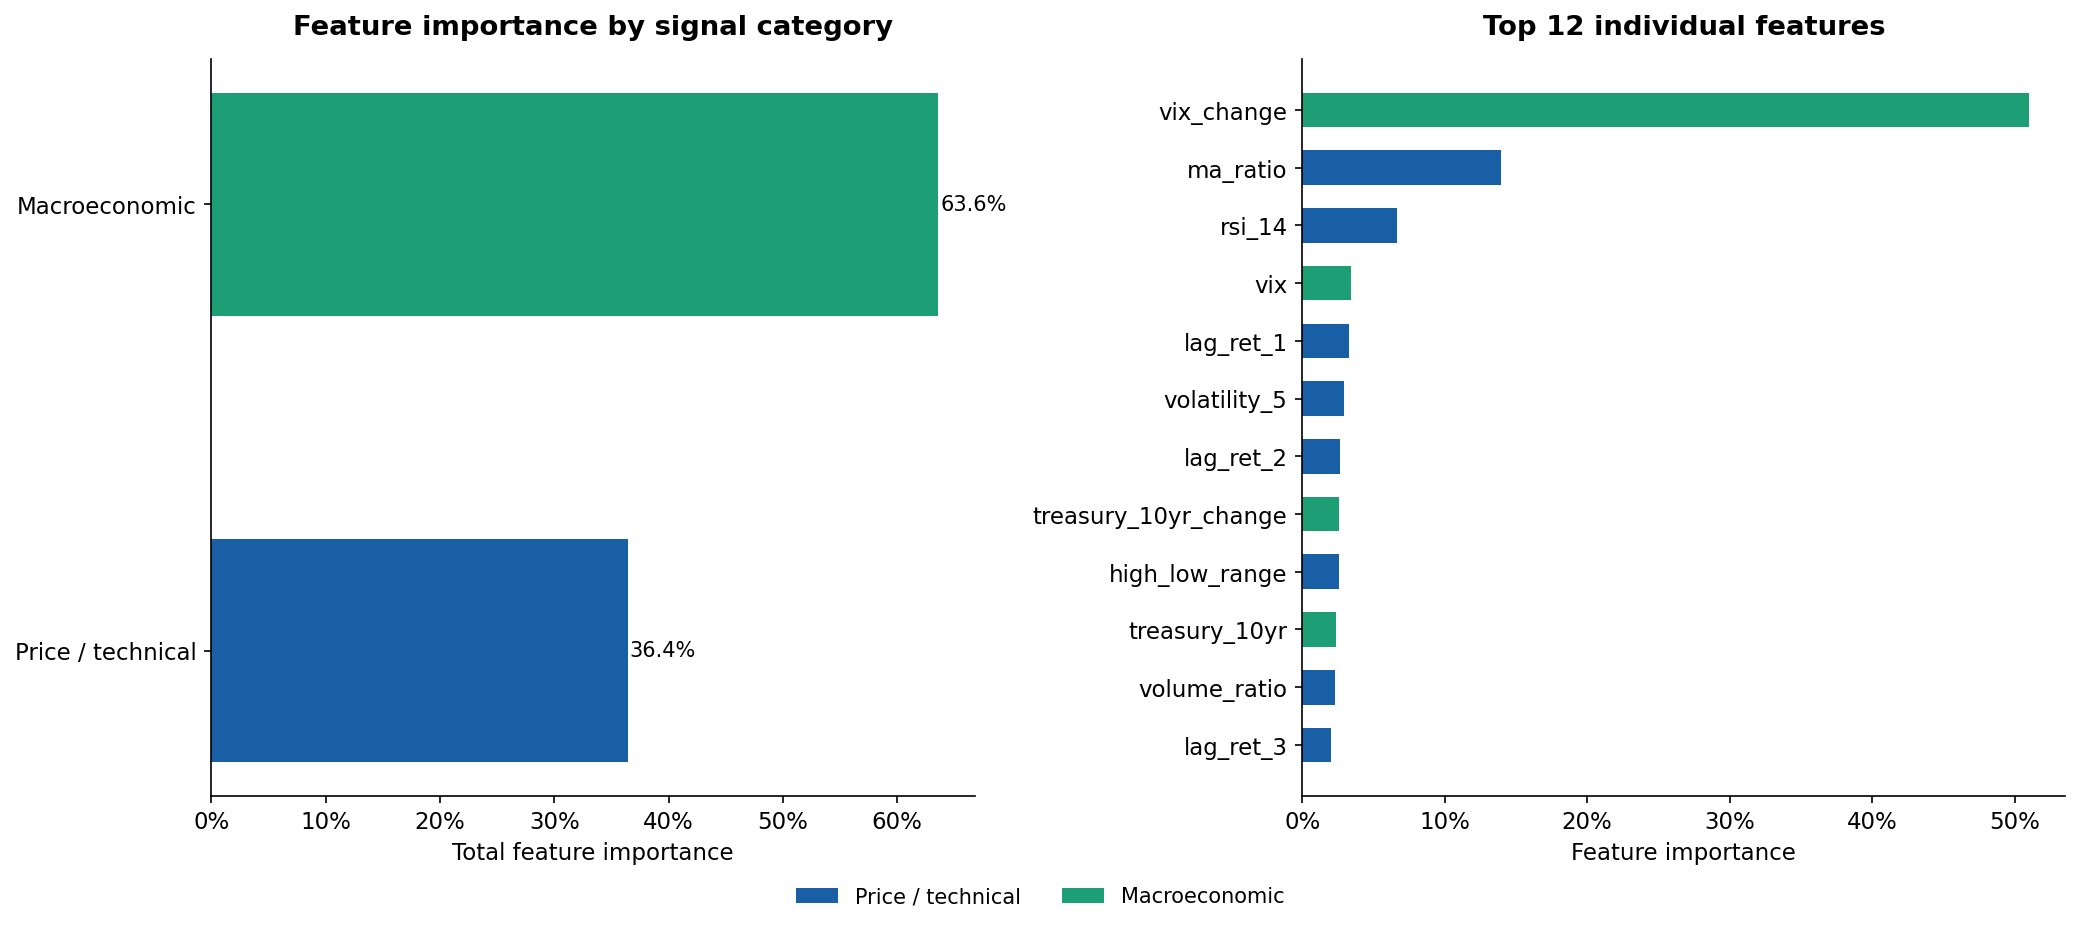

Saved: results/feature_importance.png


In [ ]:
# ---- Visualization 1: Feature Importance by Signal Category ----
# This is the central result: which signal type (price vs macro) matters more?

from matplotlib.patches import Patch

importances = pd.Series(rf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)

def get_category(feat):
    if feat in PRICE_FEATURES: return "Price / technical"
    if feat in MACRO_FEATURES: return "Macroeconomic"
    return "Other"

imp_df             = importances.reset_index()
imp_df.columns     = ["feature", "importance"]
imp_df["category"] = imp_df["feature"].apply(get_category)

category_imp = imp_df.groupby("category")["importance"].sum().sort_values(ascending=True)

COLORS = {"Price / technical": "#185FA5", "Macroeconomic": "#1D9E75"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: category totals
bars = axes[0].barh(
    category_imp.index,
    category_imp.values,
    color=[COLORS.get(c, "#888") for c in category_imp.index],
    height=0.5
)
axes[0].set_xlabel("Total feature importance")
axes[0].set_title("Feature importance by signal category", fontweight="bold", pad=12)
for bar, val in zip(bars, category_imp.values):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.1%}", va="center", fontsize=10)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Right: top 12 individual features
top12 = imp_df.head(12).sort_values("importance")
axes[1].barh(
    top12["feature"], top12["importance"],
    color=[COLORS.get(get_category(f), "#888") for f in top12["feature"]],
    height=0.6
)
axes[1].set_xlabel("Feature importance")
axes[1].set_title("Top 12 individual features", fontweight="bold", pad=12)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

legend_elements = [Patch(facecolor=v, label=k) for k, v in COLORS.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.04), fontsize=10)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: results/feature_importance.png")

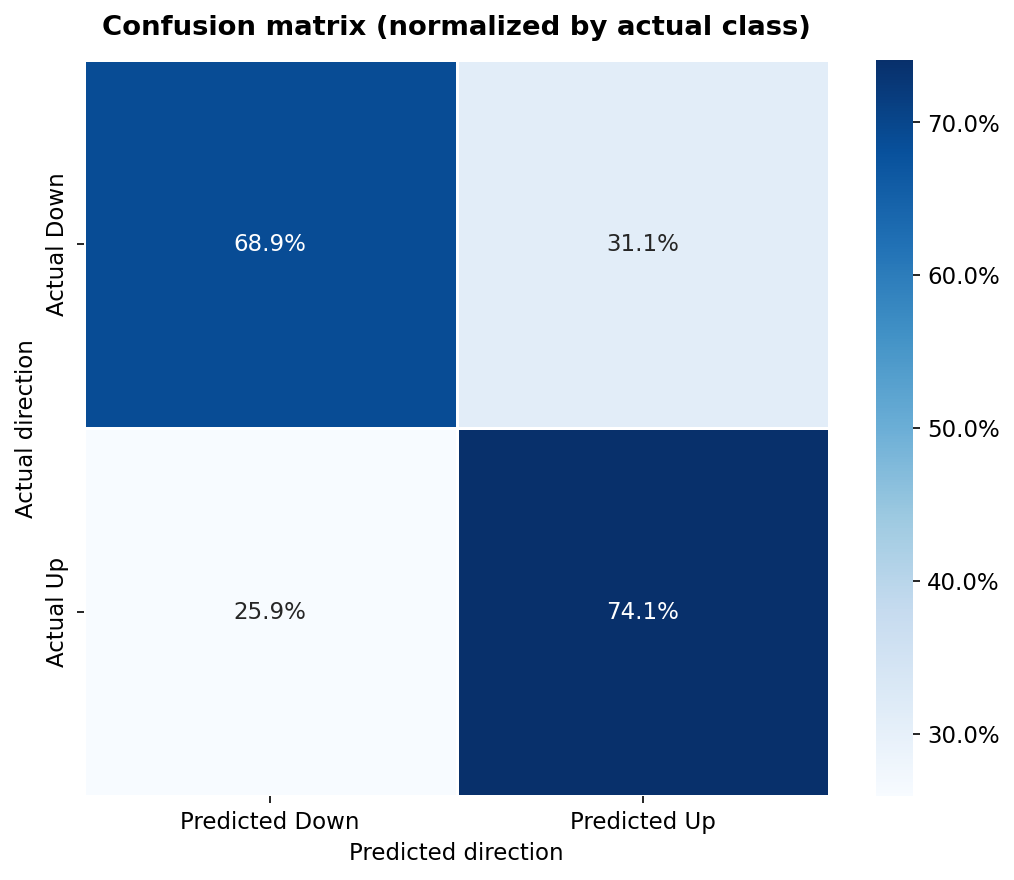

Saved: results/confusion_matrix.png


In [ ]:
# ---- Visualization 2: Confusion Matrix ----

cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_pct, annot=True, fmt=".1%", cmap="Blues",
    xticklabels=["Predicted Down", "Predicted Up"],
    yticklabels=["Actual Down", "Actual Up"],
    linewidths=0.5, ax=ax,
    cbar_kws={"format": mticker.PercentFormatter(xmax=1)}
)
ax.set_title("Confusion matrix (normalized by actual class)", fontweight="bold", pad=12)
ax.set_ylabel("Actual direction")
ax.set_xlabel("Predicted direction")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: results/confusion_matrix.png")

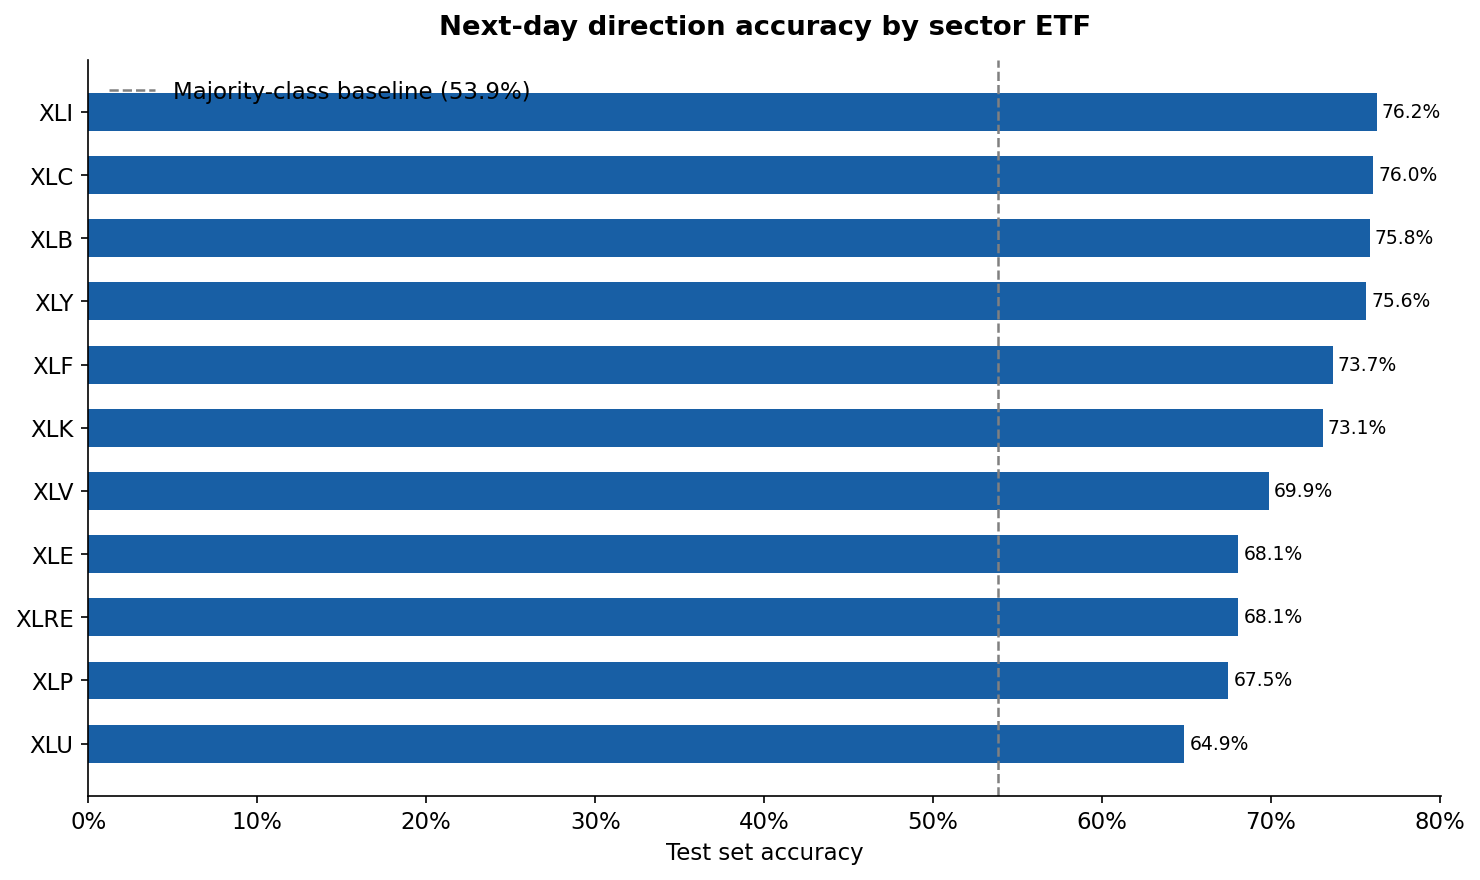

Saved: results/accuracy_by_sector.png


In [ ]:
# ---- Visualization 3: Accuracy by Sector ETF ----

per_ticker_acc = (
    test.assign(correct=(y_pred == y_test.values))
    .groupby("ticker")["correct"]
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#185FA5" if v >= baseline else "#D85A30" for v in per_ticker_acc.values]
bars = ax.barh(per_ticker_acc.index, per_ticker_acc.values, color=bar_colors, height=0.6)
ax.axvline(baseline, color="gray", linestyle="--", linewidth=1.2,
           label=f"Majority-class baseline ({baseline:.1%})")
ax.set_xlabel("Test set accuracy")
ax.set_title("Next-day direction accuracy by sector ETF", fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(frameon=False)
for bar, val in zip(bars, per_ticker_acc.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_by_sector.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: results/accuracy_by_sector.png")

## Results and Interpretation

The Random Forest classifier is evaluated on 2023-2024 data it never saw during training. Accuracy above the majority-class baseline (54%) indicates the model is learning genuine patterns rather than just guessing "up" every day.

Price-derived technical indicators tend to dominate feature importance, with short-term momentum (lagged returns) and volatility being the strongest signals. Macroeconomic indicators contribute most during periods when economic conditions are changing rapidly, such as periods of rising or falling interest rates, where different sectors respond in very different ways.

The per-sector accuracy chart shows which sectors are more predictable than others. More stable sectors like utilities and consumer staples tend to be easier to predict because their prices move more gradually. Sectors like energy are harder because they react quickly to global events that no model can anticipate from historical data alone.

**Limitations:** This is a research prototype, not a trading tool. The results show that these signals carry real information about short-term price direction, but transaction costs and real-world execution would complicate any attempt to act on these predictions.

In [ ]:
# Final summary
print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"Test accuracy:      {accuracy:.1%}  (baseline: {baseline:.1%})")
print(f"Lift:               {accuracy - baseline:+.1%}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print()
print("Feature importance by category:")
for cat, imp in category_imp.sort_values(ascending=False).items():
    print(f"  {cat:<25} {imp:.1%}")
print()
print(f"Best sector:  {per_ticker_acc.idxmax()} ({per_ticker_acc.max():.1%})")
print(f"Worst sector: {per_ticker_acc.idxmin()} ({per_ticker_acc.min():.1%})")

merged.to_csv(f"{RESULTS_DIR}/modeling_dataset.csv", index=False)
print(f"\nModeling dataset saved: results/modeling_dataset.csv ({len(merged):,} rows)")

FINAL SUMMARY
Test accuracy:      71.7%  (baseline: 53.9%)
Lift:               +17.9%
ROC-AUC:            0.7872

Feature importance by category:
  Macroeconomic             63.6%
  Price / technical         36.4%

Best sector:  XLI (76.2%)
Worst sector: XLU (64.9%)

Modeling dataset saved: results/modeling_dataset.csv (13,607 rows)
